<a href="https://colab.research.google.com/github/Nahmadid/Data_Science_Projects/blob/main/RAJ_opt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#@title install
!pip install jaxopt lineax equinox pyDOE tqdm optimistix

In [3]:
#@title libs

import functools as ft
import lineax as lx
from collections.abc import Callable
from typing import Any, TypeVar
import equinox.internal as eqxi
from jaxtyping import Array, PyTree, Scalar
from typing import NamedTuple
import numpy as np
from pyDOE import lhs
import matplotlib.pyplot as plt
import os
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import scipy
import optax
import matplotlib.pyplot as plt
import sys
from tqdm import tqdm
import scipy.io as sio
import math
import json
import chex
import optimistix as optx
from scipy.interpolate import griddata
import time




In [4]:
#@title opt funcs

Y = TypeVar("Y")
Out = TypeVar("Out")
Aux = TypeVar("Aux")




class DoglegMax(optx.AbstractGaussNewton[Y, Out, Aux]):
    """Dogleg with trust region shape given by the max norm instead of the two norm."""

    rtol: float
    atol: float
    norm: Callable[[PyTree], Scalar]
    descent: optx.DoglegDescent[Y]
    search: optx.ClassicalTrustRegion[Y]
    verbose: frozenset[str]

    def __init__(
        self,
        rtol: float,
        atol: float,
    ):
        self.rtol = rtol
        self.atol = atol
        self.norm = optx.max_norm
        self.descent = optx.DoglegDescent(
            linear_solver=lx.AutoLinearSolver(well_posed=False),
            root_finder=optx.Bisection(rtol=0.001, atol=0.001),
            trust_region_norm=optx.max_norm,
        )
        self.search = optx.ClassicalTrustRegion()
        self.verbose = frozenset()


class BFGSTrustRegion(optx.AbstractBFGS):
    """Standard BFGS + classical trust region update."""
    rtol: float
    atol: float
    norm: Callable = optx.max_norm
    use_inverse: bool = False
    search: optx.AbstractSearch = optx.LinearTrustRegion()
    descent: optx.AbstractDescent = optx.NewtonDescent()
    verbose: frozenset[str] = frozenset()


class BFGSDogleg(optx.AbstractBFGS):
    """BFGS Hessian + dogleg update."""
    rtol: float
    atol: float
    norm: Callable = optx.max_norm
    use_inverse: bool = False
    search: optx.AbstractSearch = optx.ClassicalTrustRegion()
    descent: optx.AbstractDescent = optx.DoglegDescent(linear_solver=lx.SVD())
    verbose: frozenset[str] = frozenset()

class BFGSBacktracking(optx.AbstractBFGS):
    """Standard BFGS + backtracking line search."""

    rtol: float
    atol: float
    norm: Callable = optx.max_norm
    use_inverse: bool = False
    search: optx.AbstractSearch = optx.BacktrackingArmijo()
    descent: optx.AbstractDescent = optx.NewtonDescent()
    verbose: frozenset[str] = frozenset()


class BFGSDampedNewton(optx.AbstractBFGS):
    """BFGS Hessian + direct Levenberg Marquardt update."""

    rtol: float
    atol: float
    norm: Callable = optx.max_norm
    use_inverse: bool = False
    search: optx.AbstractSearch = optx.ClassicalTrustRegion()
    descent: optx.AbstractDescent = optx.DampedNewtonDescent()
    verbose: frozenset[str] = frozenset()


class BFGSIndirectDampedNewton(optx.AbstractBFGS):
    """BFGS Hessian + indirect Levenberg Marquardt update."""

    rtol: float
    atol: float
    norm: Callable = optx.max_norm
    use_inverse: bool = False
    search: optx.AbstractSearch = optx.ClassicalTrustRegion()
    descent: optx.AbstractDescent = optx.IndirectDampedNewtonDescent()
    verbose: frozenset[str] = frozenset()


In [28]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib as mpl
import optax
import time
import pandas as pd
# import jaxopt
from scipy.integrate import odeint


def drug_model(
    t,
    kg = 0.72,
    kb = 0.15,
    G0 = 0.1,
):
    def func(y, t):
        G, B, U = y[0], y[1], y[2]

        return [
            - kg * G,
            kg * G - kb * B,
            kb * B,
            ]

    y0 = [G0, 0, 0]
    return odeint(func, y0, t)


t_dense = jnp.linspace(0, 50, 501)[:, None]
y_dense = drug_model(np.ravel(t_dense))

sample_rate = 10
dp=  500/sample_rate
t_data = t_dense[::sample_rate,0:1]
G_data = y_dense[::sample_rate,0:1]
B_data = y_dense[::sample_rate,1:2]
U_data = y_dense[::sample_rate,2:3]

data = jnp.concatenate([G_data, B_data, U_data], axis=1)
t_i  = jnp.array([[0]])
IC   = jnp.concatenate([G_data[0:1,:], B_data[0:1,:], U_data[0:1,:]], axis=1)




tmin, tmax = t_dense[0,0], t_dense[-1,0]

################################################################

############cheby #####################################
#Initialize layer parameters for the KAN model
def init_layer_kan(in_dim, out_dim, degree):
    std = 1 / (in_dim * (degree + 1))
    W = jnp.array(np.random.normal(loc=0.0, scale=std, size=(in_dim, out_dim, degree + 1)))
    b = jnp.zeros(out_dim)
    g = jnp.ones(out_dim)
    return {"W": W, "b": b, "g": g}
    # return {"W": W, "b": b}

# Initialize parameters for KAN model
def init_params_kan(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        B = jax.random.normal(key, shape=(n_out,))
        g = jax.random.normal(key, shape=(n_out,))  # Weight normalization factor `g`
        params.append({'W': W, 'B': B, 'g': g})
        # params.append({'W': W, 'B': B})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(n_in)
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params


def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        B = jax.random.normal(key, shape=(n_out,))
        g = jax.random.normal(key, shape=(n_out,))  # Weight normalization factor `g`
        params.append({'W': W, 'B': B, 'g': g})
        # params.append({'W': W, 'B': B})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(n_in)
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# Recursive Chebyshev polynomial function
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

# Cosine-based Chebyshev polynomial function
def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# Forward pass using Chebyshev interpolation and weight normalization
# def fwd(params, t, activation=jax.nn.tanh, use_cosine=False):
def fwd(params, t, activation=jax.nn.tanh, use_cosine=False):
    t = 0.01 * t
    X = t.reshape((-1, 1))  # Reshape input to have a single feature dimension

    *hidden, last = params
    for layer in hidden:
        # Apply Chebyshev interpolation (using W as Chebyshev coefficients)
        cheby_coeffs = layer['W']
        input_dim = cheby_coeffs.shape[0]
        degree = cheby_coeffs.shape[2] - 1

        # Apply Chebyshev polynomials to X
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)

        # Perform matrix multiplication using einsum
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)

        # Weight normalization
        X = layer['g'] * X + layer['B']

        # Apply activation function
        X = activation(X)

    # Last layer (no activation)
    return X @ last['W'] + last['B']

def fwd2(params, t, activation=jax.nn.tanh, use_cosine=False):
    t = 0.01 * t
    X = t.reshape((-1, 1))  # Reshape input to have a single feature dimension

    *hidden, last = params
    for layer in hidden:
        # Apply Chebyshev interpolation (using W as Chebyshev coefficients)
        cheby_coeffs = layer['W']
        input_dim = cheby_coeffs.shape[0]
        degree = cheby_coeffs.shape[2] - 1

        # Apply Chebyshev polynomials to X
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)

        # Perform matrix multiplication using einsum
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)

        # Weight normalization
        X = layer['g'] * X + layer['B']

        # Apply activation function
        X = activation(X)

    # Last layer (no activation)
    return X @ last['W'] + last['B']
#######################################################


@jax.jit
def MSE(true,pred):
  return jnp.mean((true-pred)**2)



def ODE_loss(t, y1, y2, y3, f_t):
    kg = 0.72
    kb = 0.15
    G0 = 0.1

    y1_t = lambda t: jax.grad(lambda t: jnp.sum(y1(t)))(t)
    y2_t = lambda t: jax.grad(lambda t: jnp.sum(y2(t)))(t)
    y3_t = lambda t: jax.grad(lambda t: jnp.sum(y3(t)))(t)
    ode1 = y1_t(t) + kg * y1(t)
    ode2 = y2_t(t) - f_t(t)
    ode3 = y3_t(t) - kb * y2(t)

    return ode1, ode2, ode3




#collocation points
N_c = 500

t_c = jnp.linspace(tmin, tmax, N_c+1)[:, None]

def loss_fun(params, params_extra,l1 ,l2 ,l3 , t_i, t_d, t_c, data_IC, data):
# def loss_fun(params, l1 ,l2 ,l3 , t_i, t_d, t_c, data_IC, data):

    y1_func = lambda t: fwd(params, t)[:, [0]]
    y2_func = lambda t: fwd(params, t)[:, [1]]
    y3_func = lambda t: fwd(params, t)[:, [2]]
    f_t     = lambda t: fwd2(params_extra, t)[:, [0]]


    loss_y1, loss_y2, loss_y3 = ODE_loss(t_c, y1_func, y2_func, y3_func, f_t)

    loss_y1 = l1*loss_y1
    loss_y2 = l2*loss_y2
    loss_y3 = l3*loss_y3

    loss_ode1 = jnp.mean(loss_y1 ** 2)
    loss_ode2 = jnp.mean(loss_y2 ** 2)
    loss_ode3 = jnp.mean(loss_y3 ** 2)


    # Compute the loss for the initial conditions
    t_i = t_i.flatten()[:,None]
    pred_IC = jnp.concatenate([y1_func(t_i), y2_func(t_i), y3_func(t_i)],axis=1)
    loss_IC = MSE(data_IC, pred_IC)

    # Compute the loss for Y_data
    t_d    = t_d.flatten()[:,None]
    pred_d = jnp.concatenate([y1_func(t_d), y2_func(t_d), y3_func(t_d)],axis=1)
    loss_data = MSE(data, pred_d)


    return loss_IC, loss_data, loss_ode1, loss_ode2, loss_ode3


def loss_fun_total(params, params_extra,l1,l2, l3, t_i, t_d, t_c, data_IC, data, loss_weight):
# def loss_fun_total(params, l1,l2, l3, t_i, t_d, t_c, data_IC, data, loss_weight):

    loss_IC, loss_data, loss_ode1, loss_ode2, loss_ode3 = loss_fun(params, params_extra,l1,l2, l3, t_i, t_d, t_c, data_IC, data)
    # loss_IC, loss_data, loss_ode1, loss_ode2, loss_ode3 = loss_fun(params, l1,l2, l3, t_i, t_d, t_c, data_IC, data)

    loss_total = loss_weight[0]*loss_IC+ loss_weight[1]*loss_data\
                + loss_weight[2]*loss_ode1+ loss_weight[3]*loss_ode2\
                + loss_weight[4]*loss_ode3

    return loss_total







@jax.jit
def update(opt_state, opt_state_extra, params, params_extra, params_l1, params_l2, params_l3, opt_state_l1,opt_state_l2, opt_state_l3, t_i, t_data, t_c, IC, data, loss_weight):
  grads=jax.grad(loss_fun_total, argnums=[0,1,2,3,4])(params, params_extra,params_l1, params_l2, params_l3, t_i, t_data, t_c, IC, data, loss_weight)

  #Update params
  updates, opt_state = optimizer.update(grads[0], opt_state, params)
  params = optax.apply_updates(params, updates)

  updates_extra, opt_state_extra = optimizer_ex.update(grads[1], opt_state_extra, params_extra)
  params_extra = optax.apply_updates(params_extra, updates_extra)

  updates_l1, opt_state_l1 = optimizer.update(-grads[2], opt_state_l1, params_l1)
  params_l1 = optax.apply_updates(params_l1, updates_l1)

  updates_l2, opt_state_l2 = optimizer.update(-grads[3], opt_state_l2, params_l2)
  params_l2 = optax.apply_updates(params_l2, updates_l2)

  updates_l3, opt_state_l3 = optimizer.update(-grads[4], opt_state_l3, params_l3)
  params_l3 = optax.apply_updates(params_l3, updates_l3)

  return opt_state,params,opt_state_extra,params_extra, params_l1, params_l2, params_l3, opt_state_l1,opt_state_l2, opt_state_l3





########################################
layers = [1, 50, 50, 3]  # Input layer, 2 hidden layers, and output layer
layers_ex = [1, 20, 20,20, 1]
dg1=1
dg2=1

########################################

epochs_phase1 = 100
epochs_phase2 = 1000

scheduler = optax.cosine_decay_schedule(
    init_value=0.01,        # Initial learning rate
    decay_steps=epochs_phase1 + epochs_phase2 ,     # Total number of steps over which the decay will happen
    alpha=0.0              # The final value (0 means it will approach 0 at the end)
)
params = init_params_kan(layers, degree=dg1)
params_extra = init_params_kan2(layers_ex, degree=dg2)
optimizer = optax.radam(learning_rate=scheduler)  # Specify the weight decay if needed  # Specify the weight decay if needed
opt_state = optimizer.init(params)

optimizer_ex = optax.radam(learning_rate=scheduler)
opt_state_extra = optimizer_ex.init(params_extra)


keys = jax.random.split(jax.random.PRNGKey(0), 3)

lambda_1 = jax.random.uniform(keys[0], shape=(N_c + 1, 1))
lambda_2 = jax.random.uniform(keys[1], shape=(N_c + 1, 1))
lambda_3 = jax.random.uniform(keys[2], shape=(N_c + 1, 1))

opt_state_l1 = optimizer.init(lambda_1)
opt_state_l2 = optimizer.init(lambda_2)
opt_state_l3 = optimizer.init(lambda_3)

#@title **two step training**


start_time = time.time()


loss_weight_phase1 = [1, 1, 0, 0, 0]
loss_weight_phase2 = [1, 1, 1, 1, 1]

loss_his, loss_indi_his, epoch_his = [], [], []

for ep in range(epochs_phase1 + epochs_phase2 + 1):
    if ep <= epochs_phase1:
        loss_weight = loss_weight_phase1
    else:
        loss_weight = loss_weight_phase2

    opt_state,params,opt_state_extra,\
    params_extra, params_l1, params_l2,\
    params_l3, opt_state_l1,opt_state_l2, opt_state_l3 = update(opt_state, opt_state_extra, params, params_extra,\
                                                             lambda_1, lambda_2, lambda_3, opt_state_l1,\
                                                              opt_state_l2, opt_state_l3, t_i, t_data, t_c, IC, data, loss_weight)

    # print loss and epoch info
    if ep %(100) ==0:
      loss_val = loss_fun_total(params,params_extra, params_l1, params_l2, params_l3, t_i, t_data, t_c, IC, data, loss_weight)
      loss_val_individual = loss_fun(params,params_extra, params_l1, params_l2, params_l3, t_i, t_data, t_c, IC, data)
      epoch_his.append(ep)
      loss_his.append(loss_val)
      loss_indi_his.append(loss_val_individual)
      print(f'Epoch={ep}, \t loss={loss_val:.3e}, \t loss_IC={loss_val_individual[0]:.3e}, \t loss_d={loss_val_individual[1]:.3e}, \t loss_e1={loss_val_individual[2]:.3e}, \t loss_e2={loss_val_individual[3]:.3e}, \t loss_e3={loss_val_individual[4]:.3e}')
      end_time = time.time()

      running_time = end_time - start_time
      print(f"Total running time: {running_time:.4f} seconds")




kg = 0.72
kb = 0.15
G0 = 0.1

pred = fwd(params,t_dense)

# Subplot 2: f(t) analytical vs. neural
f = fwd2(params_extra,t_dense)
f_t_analytical = kg * y_dense[:, 0] - kb * y_dense[:, 1]
f_t_neural = f[:, 0]


#############################################################
import pandas as pd
import matplotlib.pyplot as plt

ft_10 = f[:, 0]

#-------------------------------------------------
f_t_analytical = kg * y_dense[:, 0] - kb * y_dense[:, 1]

#-------------------------------------------------

def compute_errors(true_values, predicted_values):
    # Compute Mean Absolute Error (MAE)
    mae = np.abs(true_values - predicted_values).mean()

    # Compute Root Mean Squared Error (RMSE)
    rmse = np.sqrt(((true_values - predicted_values) ** 2).mean())

    # Compute Relative Error (RE)
    numerator = np.sqrt(np.sum((true_values - predicted_values) ** 2))
    denominator = np.sqrt(np.sum(true_values ** 2))
    re = numerator / denominator

    return mae, rmse, re

# Extract the true values and predicted values from the CSV data

# Calculate L1, L2, L∞, and L2 relative errors

print(f"_____________{dp} data points______________")
print(f"{epochs_phase1} +{epochs_phase2}   ")

print('_____________  error with radam ______________')
mae, rmse, re  = compute_errors(f_t_analytical, ft_10)
print(f"(MAE): {mae:.2e}")
print(f"(RMSE): {rmse:.2e}")
print(f"(RE): {re:.2e}")






Epoch=0, 	 loss=3.945e-02, 	 loss_IC=1.233e-02, 	 loss_d=2.712e-02, 	 loss_e1=2.620e-03, 	 loss_e2=2.754e-02, 	 loss_e3=2.139e-05
Total running time: 4.6898 seconds
Epoch=100, 	 loss=1.573e-03, 	 loss_IC=6.040e-04, 	 loss_d=9.689e-04, 	 loss_e1=2.293e-04, 	 loss_e2=2.769e-02, 	 loss_e3=5.114e-07
Total running time: 5.2201 seconds
Epoch=200, 	 loss=1.254e-03, 	 loss_IC=3.002e-04, 	 loss_d=7.345e-04, 	 loss_e1=2.178e-04, 	 loss_e2=1.300e-06, 	 loss_e3=4.189e-07
Total running time: 5.7444 seconds
Epoch=300, 	 loss=1.186e-03, 	 loss_IC=2.510e-04, 	 loss_d=7.196e-04, 	 loss_e1=2.135e-04, 	 loss_e2=8.256e-07, 	 loss_e3=1.164e-06
Total running time: 6.2716 seconds
Epoch=400, 	 loss=1.152e-03, 	 loss_IC=2.393e-04, 	 loss_d=7.050e-04, 	 loss_e1=2.061e-04, 	 loss_e2=5.361e-07, 	 loss_e3=1.163e-06
Total running time: 6.7870 seconds
Epoch=500, 	 loss=1.104e-03, 	 loss_IC=2.248e-04, 	 loss_d=6.822e-04, 	 loss_e1=1.951e-04, 	 loss_e2=3.532e-07, 	 loss_e3=1.118e-06
Total running time: 7.3198 seconds


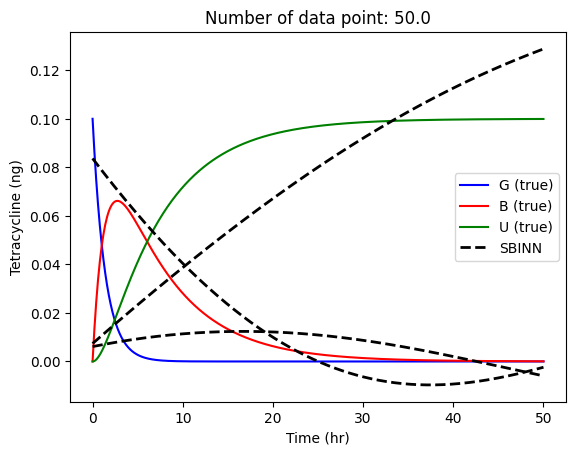

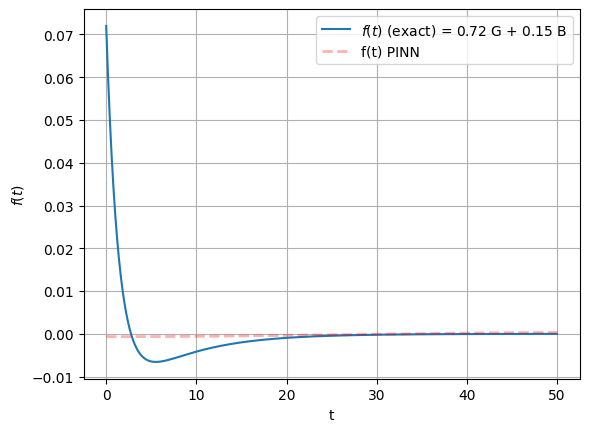

In [29]:
pred = fwd(params,t_dense)
plt.figure()
plt.plot(t_dense, y_dense[:, 0:1],'-b',label='G (true)')
plt.plot(t_dense, y_dense[:, 1:2],'-r',label='B (true)')
plt.plot(t_dense, y_dense[:, 2:3],'-g',label='U (true)')

plt.plot(t_dense,pred[:,0],'--k',label='SBINN',linewidth=2)
plt.plot(t_dense,pred[:,1],'--k',linewidth=2)
plt.plot(t_dense,pred[:,2],'--k',linewidth=2)
plt.title(f'Number of data point: {dp}')
plt.xlabel('Time (hr)')
plt.ylabel('Tetracycline (ng)')
plt.legend()
plt.savefig('./Pred.png', dpi=300)


f_t_analytical = kg * y_dense[:, 0] - kb * y_dense[:, 1]
f_t_neural = fwd2(params_extra, t_dense)[:, 0]


plt.figure()
# F_SR= 0.739 *y_dense[:, 0]- 0.141* y_dense[:, 1]
# f_t_neural = fwd_extra(loaded_params_extra, t_dense)[:, 0]
# Plot both f_t values
plt.plot(t_dense, f_t_analytical, label='$f(t)$ (exact) = 0.72 G + 0.15 B')
plt.plot(t_dense, f_t_neural,'--r',linewidth=2, label='f(t) PINN', alpha=0.3)
# plt.plot(t_dense, F_SR ,'--k', label='$f(t)$ (Symbolic Regression)= 0.739 G + 0.141 B ')
plt.grid()
plt.xlabel('t')
plt.ylabel('$f(t)$')
plt.legend()
plt.savefig('./ft.png', dpi=300)

In [30]:
#############################################



params_total = []
params_total.append(params)
params_total.append(params_extra)
params_total.append(params_l1)
params_total.append(params_l2)
params_total.append(params_l3)

loss_weight = loss_weight_phase2

static = []
static.append(t_i)
static.append(t_data)
static.append(t_c)
static.append(IC)
static.append(data)
static.append(loss_weight)



# def loss_fun_total_lbfgs(params_total, t_i, t_d, t_c, data_IC, data, loss_weight):
def loss_fun_total_lbfgs(params_total, static):
    params, params_extra, l1,l2, l3 = params_total#[0], params_total[1], params_total[2], params_total[3], params_total[4]
    t_i, t_d, t_c, data_IC, data, loss_weight = static
    loss_IC, loss_data, loss_ode1, loss_ode2, loss_ode3 = loss_fun(params, params_extra,l1 ,l2, l3, t_i, t_d, t_c, data_IC, data)
    loss_total = loss_weight[0]*loss_IC+ loss_weight[1]*loss_data\
                + loss_weight[2]*loss_ode1+ loss_weight[3]*loss_ode2\
                + loss_weight[4]*loss_ode3

    return loss_total

print('___________second optimizer____________')



solver = BFGSTrustRegion(rtol=1e-11, atol=1e-11, verbose=["loss"])
#solver = BFGSDogleg(rtol=1e-7, atol=1e-7, verbose=["loss"])
solver = optx.BestSoFarMinimiser(solver)
epochs_phase = 100

t3 = time.time()
sol = optx.minimise(loss_fun_total_lbfgs, solver, params_total, args=static, max_steps=30000, throw=False)
t4 = time.time()
print(f"Elapsed time for BFGS: {t4-t3} sec")
bfgs_steps =  sol.stats["num_steps"]
print(f"BFGS Steps: {bfgs_steps}")
# params_total = sol.value



___________second optimizer____________
Loss on this step: 0.0007235429948195815, Loss on the last accepted step: 0.0
Loss on this step: 0.0007232785574160516, Loss on the last accepted step: 0.0007235429948195815
Loss on this step: 0.0007742883171886206, Loss on the last accepted step: 0.0007232785574160516
Loss on this step: 0.0007187586161307991, Loss on the last accepted step: 0.0007232785574160516
Loss on this step: 0.0006331762415356934, Loss on the last accepted step: 0.0007187586161307991
Loss on this step: 0.0012322637485340238, Loss on the last accepted step: 0.0006331762415356934
Loss on this step: 0.0006354510551318526, Loss on the last accepted step: 0.0006331762415356934
Loss on this step: 0.0006255311891436577, Loss on the last accepted step: 0.0006331762415356934
Loss on this step: 0.000623592990450561, Loss on the last accepted step: 0.0006255311891436577
Loss on this step: 0.0006171825225465, Loss on the last accepted step: 0.000623592990450561
Loss on this step: 0.00

_____________  error with adam + lbfgs ______________
(MAE): 3.54e-03
(RMSE): 7.97e-03
(RE): 9.90e-01
Saved loss history to ./error_his.csv


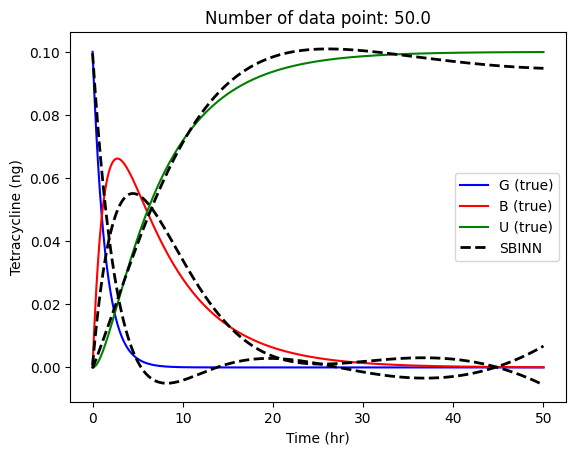

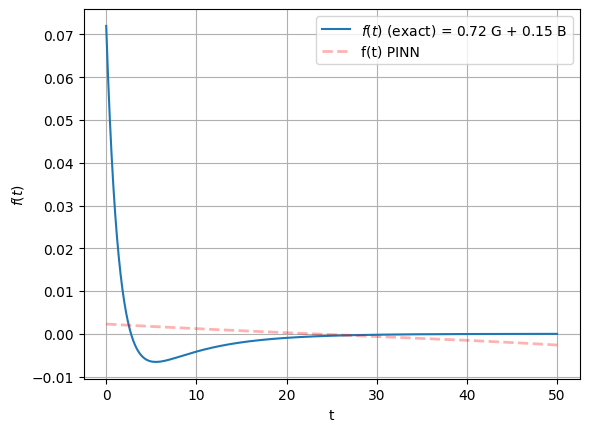

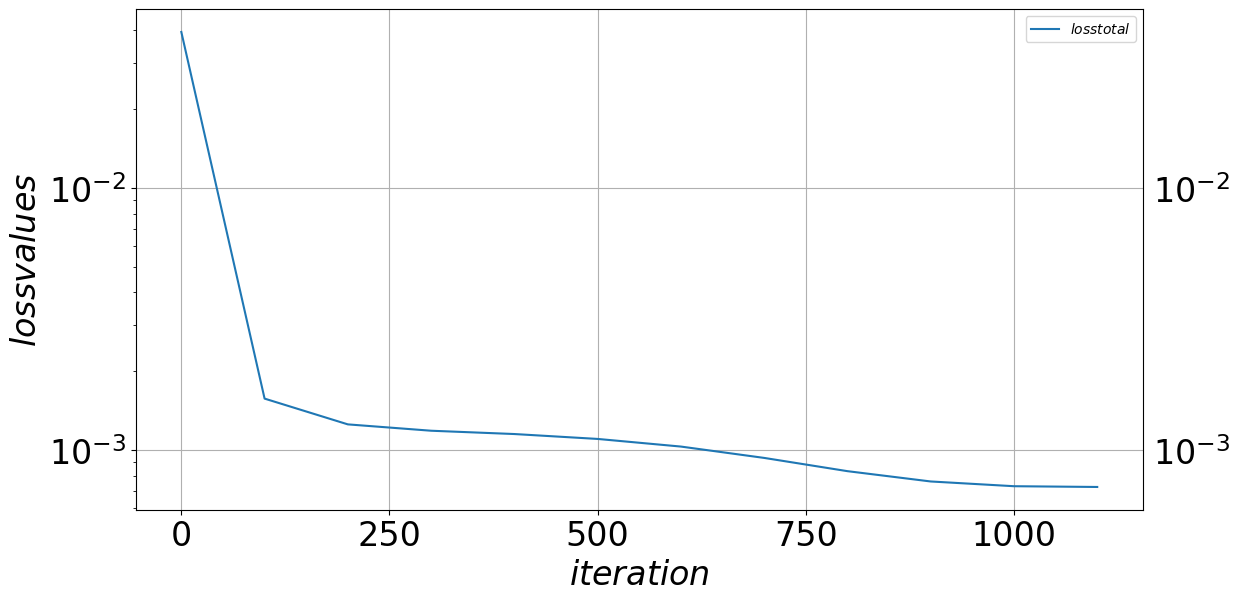

In [32]:
params_total = sol.value
params = params_total[0]
params_extra = params_total[1]
# pred = fwd(params,t_dense)
pred = fwd(params,t_dense)
plt.figure()
plt.plot(t_dense, y_dense[:, 0:1],'-b',label='G (true)')
plt.plot(t_dense, y_dense[:, 1:2],'-r',label='B (true)')
plt.plot(t_dense, y_dense[:, 2:3],'-g',label='U (true)')

plt.plot(t_dense,pred[:,0],'--k',label='SBINN',linewidth=2)
plt.plot(t_dense,pred[:,1],'--k',linewidth=2)
plt.plot(t_dense,pred[:,2],'--k',linewidth=2)
plt.title(f'Number of data point: {dp}')
plt.xlabel('Time (hr)')
plt.ylabel('Tetracycline (ng)')
plt.legend()
plt.savefig('./Pred.png', dpi=300)


f_t_analytical = kg * y_dense[:, 0] - kb * y_dense[:, 1]
f_t_neural = fwd2(params_extra, t_dense)[:, 0]


plt.figure()
# F_SR= 0.739 *y_dense[:, 0]- 0.141* y_dense[:, 1]
# f_t_neural = fwd_extra(loaded_params_extra, t_dense)[:, 0]
# Plot both f_t values
plt.plot(t_dense, f_t_analytical, label='$f(t)$ (exact) = 0.72 G + 0.15 B')
plt.plot(t_dense, f_t_neural,'--r',linewidth=2, label='f(t) PINN', alpha=0.3)
# plt.plot(t_dense, F_SR ,'--k', label='$f(t)$ (Symbolic Regression)= 0.739 G + 0.141 B ')
plt.grid()
plt.xlabel('t')
plt.ylabel('$f(t)$')
plt.legend()
plt.savefig('./ft.png', dpi=300)

t_d = jnp.linspace(0, 50, 501)[:, None]
pred = fwd(params,t_d)
f_t_neural = fwd2(params_extra, t_d)[:, 0]
G_pred = pred[:,0:1]
B_pred = pred[:,1:2]
U_pred = pred[:,2:3]
df_f = pd.DataFrame({"t": np.ravel(t_d),"G": np.ravel(G_pred), "B": np.ravel(B_pred),"U": np.ravel(U_pred) ,"ft": np.ravel(f_t_neural) })
df_f.to_csv("./pred_100.csv", index=False)

#############################################################
import pandas as pd
import matplotlib.pyplot as plt


# -------Load the CSV file into a Pandas DataFrame
df_10 = pd.read_csv(f"pred_100.csv")
# t = df_10['t']
ft_10 = df_10['ft']
# ft_10 = df_10['ft']

#-------------------------------------------------
kg = 0.72
kb = 0.15
G0 = 0.1

f_t_analytical = kg * y_dense[:, 0] - kb * y_dense[:, 1]

#-------------------------------------------------

def compute_errors(true_values, predicted_values):
    # Compute Mean Absolute Error (MAE)
    mae = np.abs(true_values - predicted_values).mean()

    # Compute Root Mean Squared Error (RMSE)
    rmse = np.sqrt(((true_values - predicted_values) ** 2).mean())

    # Compute Relative Error (RE)
    numerator = np.sqrt(np.sum((true_values - predicted_values) ** 2))
    denominator = np.sqrt(np.sum(true_values ** 2))
    re = numerator / denominator

    return mae, rmse, re

# Extract the true values and predicted values from the CSV data

# Calculate L1, L2, L∞, and L2 relative errors




print(f'_____________  error with adam + lbfgs ______________')
mae, rmse, re  = compute_errors(f_t_analytical, ft_10)
print(f"(MAE): {mae:.2e}")
print(f"(RMSE): {rmse:.2e}")
print(f"(RE): {re:.2e}")


##############################################

#############################################
# Save the history to a CSV file
loss_indi_his = np.array(loss_indi_his)  # Convert list of lists to numpy array for easier handling

# Create DataFrame
columns = ["epoch", "total_loss"]
data = {
    "epoch": epoch_his,
    "total_loss": loss_his
}
df_f = pd.DataFrame(data, columns=columns)

# Save to CSV
output_path = "./error_his.csv"
df_f.to_csv(output_path, index=False)
print(f"Saved loss history to {output_path}")
###############################################

###############################################

SAVE_FIG = True
#History of loss
font = 24
fig, ax = plt.subplots()
plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)
plt.tick_params(axis='y', which='both', labelleft='on', labelright='off')
plt.xlabel('$iteration$', fontsize = font)
plt.ylabel('$loss values$', fontsize = font)
plt.yscale('log')
plt.grid(True)
plt.plot(epoch_his, np.asarray(loss_his), label='$loss total$')
plt.legend(loc="upper right",  fontsize = 24, ncol=4)
plt.legend()
ax.tick_params(axis='both', labelsize = 24)
fig.set_size_inches(w=13,h=6.5)
if SAVE_FIG:
    plt.savefig('./total_loss.png', dpi=300)